In [1]:
INDIA_PROJECTED_CRS = "24378"

In [2]:
BACKGROUND_COLOR = "lightgreen"
BUILDING_COLOR = "yellow"
SETTLEMENT_COLOR = "darkred"
WATER_COLOR = "C0"
CROPLAND_COLOR = "goldenrod"
SLOPE_COLOR = "grey"

# Setup

In [3]:
# set libraries to refresh
%load_ext autoreload
%autoreload 2

In [4]:
from pathlib import Path
import numpy as np
import pandas as pd
import geopandas as gpd

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from shapely import MultiPolygon

In [5]:
from gridsample.utils import create_ids, save_shapefiles
from gridsample.utils_rooftop import generate_colormap
# from gridsample.mapping.plot import create_interactive_map

In [6]:
def clean_geometry(gdf):
    """Clean geometry collections and multipolygons by keeping only polygon geometries."""
    def _clean_geom(geom):
        if geom is None:
            return None
        
        # If it's already a Polygon, return as is
        if geom.geom_type == 'Polygon':
            return geom

        # Get polygons from MultiPolygon or GeometryCollection 
        polygons = []
        if hasattr(geom, 'geoms'):
            for g in geom.geoms:
                if g.geom_type == 'Polygon':
                    polygons.append(g)

        # Return appropriate geometry based on number of polygons found
        if not polygons:
            return None
        if len(polygons) == 1:
            return polygons[0]
        return MultiPolygon(polygons)

    # Apply cleaning and drop invalid geometries
    gdf = gdf.copy()
    gdf.geometry = gdf.geometry.apply(_clean_geom)
    return gdf.dropna(subset=['geometry'])

In [7]:
ROOT_DIR = Path("../")
DATA_DIR = ROOT_DIR / "data"
RAW_DATA_DIR = DATA_DIR / "00_raw"
CLEANED_DATA_DIR = DATA_DIR / "01_processed" / "Solar Parks" / "01 Cleaned Khasras"
OUTPUT_DATA_DIR = DATA_DIR / "01_processed" / "Solar Parks" / "03 Suggested Parcels" / "v6"
OUTPUT_DATA_DIR.mkdir(parents=True, exist_ok=True)

# 0. Load cleaned khasras

In [8]:
LOCATION = "Morena"
DISTRICT_MAPS_OUTPUT_DATA_DIR = OUTPUT_DATA_DIR / LOCATION / "District Maps"
DISTRICT_MAPS_OUTPUT_DATA_DIR.mkdir(parents=True, exist_ok=True)

In [9]:
morena_gdf = gpd.read_parquet(CLEANED_DATA_DIR / "morena_cleaned_khasras.parquet")
morena_gdf

,Khasra Name,Description,source,Patch Name,geometry,Khasra ID (Unique)
1,104,Unknown Area Type<BR><BR><B>patch_name</B> = M...,joura,MRA2,"POLYGON ((77.55342 25.90592, 77.55342 25.90598...",104 (MRA2)
3,106,Unknown Area Type<BR><BR><B>patch_name</B> = M...,joura,MRA2,"POLYGON ((77.55297 25.90997, 77.55296 25.90997...",106 (MRA2)
5,99,Unknown Area Type<BR><BR><B>patch_name</B> = M...,joura,MRA2,"POLYGON ((77.55723 25.90691, 77.55724 25.90690...",99 (MRA2)
7,101,Unknown Area Type<BR><BR><B>patch_name</B> = M...,joura,MRA2,"POLYGON ((77.55692 25.90755, 77.55691 25.90758...",101 (MRA2)
9,103,Unknown Area Type<BR><BR><B>patch_name</B> = M...,joura,MRA2,"POLYGON ((77.55530 25.90855, 77.55477 25.90856...",103 (MRA2)
...,...,...,...,...,...,...
17872,Unit III,"<html xmlns:fo=""http://www.w3.org/1999/XSL/For...",solar_park_boundary,6,"POLYGON ((77.65554 25.95982, 77.65599 25.96035...",Unit III (6)
17873,Unit II,"<html xmlns:fo=""http://www.w3.org/1999/XSL/For...",solar_park_boundary,7,"POLYGON ((77.64660 25.94617, 77.64650 25.94617...",Unit II (7)
17874,Unit I,"<html xmlns:fo=""http://www.w3.org/1999/XSL/For...",solar_park_boundary,8,"POLYGON ((77.64315 25.95003, 77.64339 25.95892...",Unit I (8)
17875,Unit IV,"<html xmlns:fo=""http://www.w3.org/1999/XSL/For...",solar_park_boundary,9,"POLYGON ((77.64695 25.92893, 77.64543 25.92955...",Unit IV (9)


In [10]:
gdf_4326 = morena_gdf
gdf = morena_gdf.to_crs(INDIA_PROJECTED_CRS)

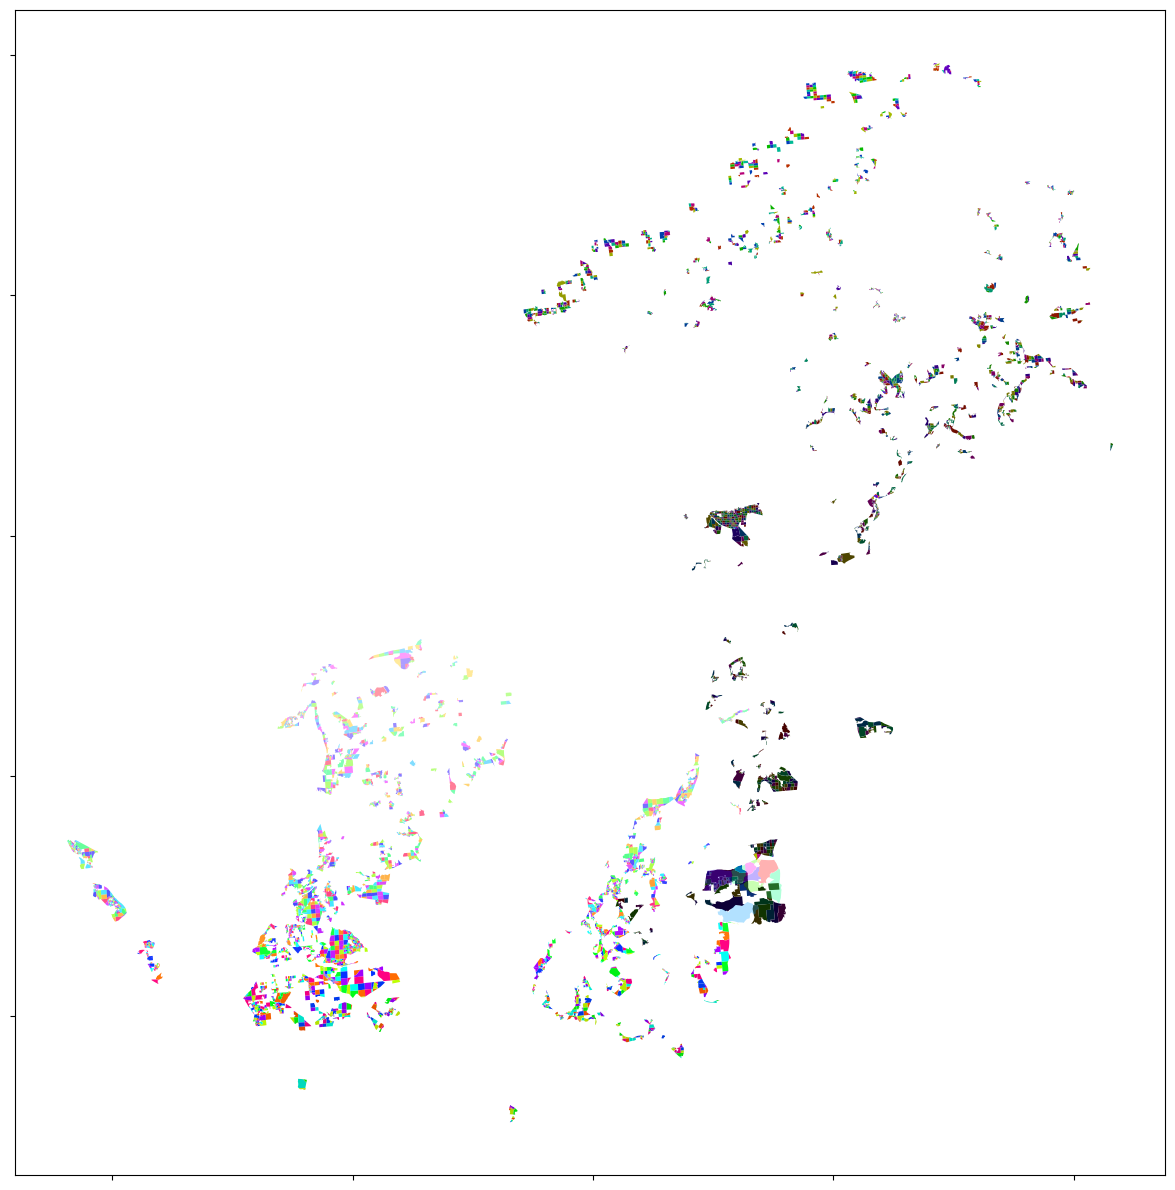

In [11]:
ax = gdf.plot(
    cmap=ListedColormap(generate_colormap(len(gdf))),
    figsize=(12, 12),
)
ax.set_xticklabels([])
ax.set_yticklabels([])

plt.tight_layout()
plt.savefig(
    DISTRICT_MAPS_OUTPUT_DATA_DIR / "khasras.png",
    dpi=300,
    bbox_inches="tight",
)

In [12]:
save_shapefiles(
    gdf.to_crs(epsg=4326),
    OUTPUT_DATA_DIR / LOCATION / "Khasra Shapefiles",
    "khasras_initial",
    formats=["parquet", "kml", "csv"],
)

## Unusable layers

Overlap layers and decide which to discard and which to take forward

### Buildings

In [13]:
from gridsample.utils_rooftop import (
    get_overlapping_s2_cell_ids,
    get_s2_cell_polygons,
    download_VIDA_rooftops_data_by_s2,
    get_matched_rooftop_centroids_from_s2_file,
)

#### Identify S2 cell IDs

In [14]:
s2_cell_ids = get_overlapping_s2_cell_ids(gdf_4326)
print("Number of unique S2 cell IDs that overlap these shapes:", len(s2_cell_ids))
print("Unique S2 cell IDs:", s2_cell_ids)

Shapes with spillover after round 1: 0
Number of unique S2 cell IDs that overlap these shapes: 2
Unique S2 cell IDs: [4139089532530196480, 4140778382390460416]


/Users/amiremami/IDinsight Repos/gridsample/gridsample/utils_rooftop.py:125: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  points = gdf.geometry.centroid.to_frame(name="geometry")


#### Check if identified cells cover all areas of interest


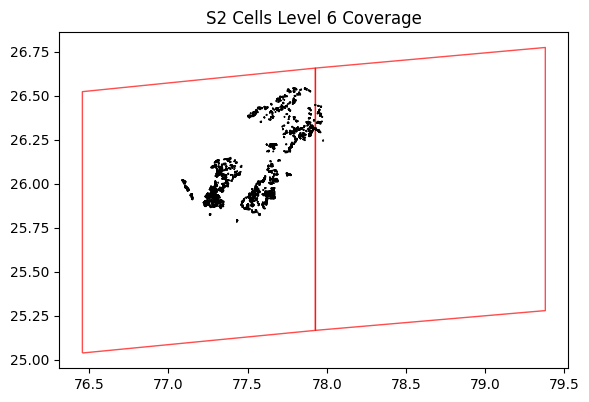

0.0 square degrees area not covered by an S2 cell


In [15]:
s2_cells_gdf = get_s2_cell_polygons(s2_cell_ids)

# Plot the S2 cells and the boundary
fig, ax = plt.subplots(1, 1, figsize=(6, 6))
gdf_4326.boundary.plot(ax=ax, color="black", linewidth=1)
s2_cells_gdf.plot(ax=ax, facecolor="none", edgecolor="red", alpha=0.7)
plt.title("S2 Cells Level 6 Coverage")
plt.tight_layout()
plt.show()
# Does the S2 cell cover the entire area of the boundaries?
uncovered_area = gdf_4326.unary_union.difference(s2_cells_gdf.unary_union).area
print(f"{uncovered_area} square degrees area not covered by an S2 cell")


In [16]:
#### Download the S2 cells
download_VIDA_rooftops_data_by_s2(
    s2_cell_ids=s2_cell_ids,
    country_iso_code="IND",
    target_data_dir=RAW_DATA_DIR / "rooftops",
)

File 4139089532530196480 already exists.
File 4140778382390460416 already exists.


#### Load and process rooftop data

In [17]:
rooftop_gdf_list = []
for s2_cell_id in s2_cell_ids:
    s2_rooftops_path = RAW_DATA_DIR / "rooftops" / f"{s2_cell_id}.parquet"
    rooftop_gdf = gpd.read_parquet(s2_rooftops_path)
    rooftop_gdf_list.append(rooftop_gdf)

rooftop_gdf = pd.concat(rooftop_gdf_list, ignore_index=True)
rooftop_gdf = rooftop_gdf[
    [
        "bf_source",
        "confidence",
        "area_in_meters",
        "geometry",
    ]
]

rooftop_gdf["rooftop_id"] = create_ids(len(rooftop_gdf), f"ROOFTOP_S2_{s2_cell_id}_")
rooftop_gdf = rooftop_gdf.to_crs(INDIA_PROJECTED_CRS)

#### Filter to only rooftops that overlap the parcels

In [18]:
subset_rooftops_gdf = rooftop_gdf.sjoin(
    gdf, how="inner", predicate="intersects"
).drop(columns=["index_right"])
subset_rooftops_gdf.drop(
    columns=gdf.columns.drop("geometry"), inplace=True
)

In [19]:
buffer = 25
buffered_rooftops_gdf = subset_rooftops_gdf.copy()
buffered_rooftops_gdf["geometry"] = buffered_rooftops_gdf.buffer(buffer)

# get cutout of the buffered building shapes that overlap parcels
buildings_overlap_gdf = gpd.overlay(
    buffered_rooftops_gdf, gdf, how="intersection"
)

#### Settlements - auto

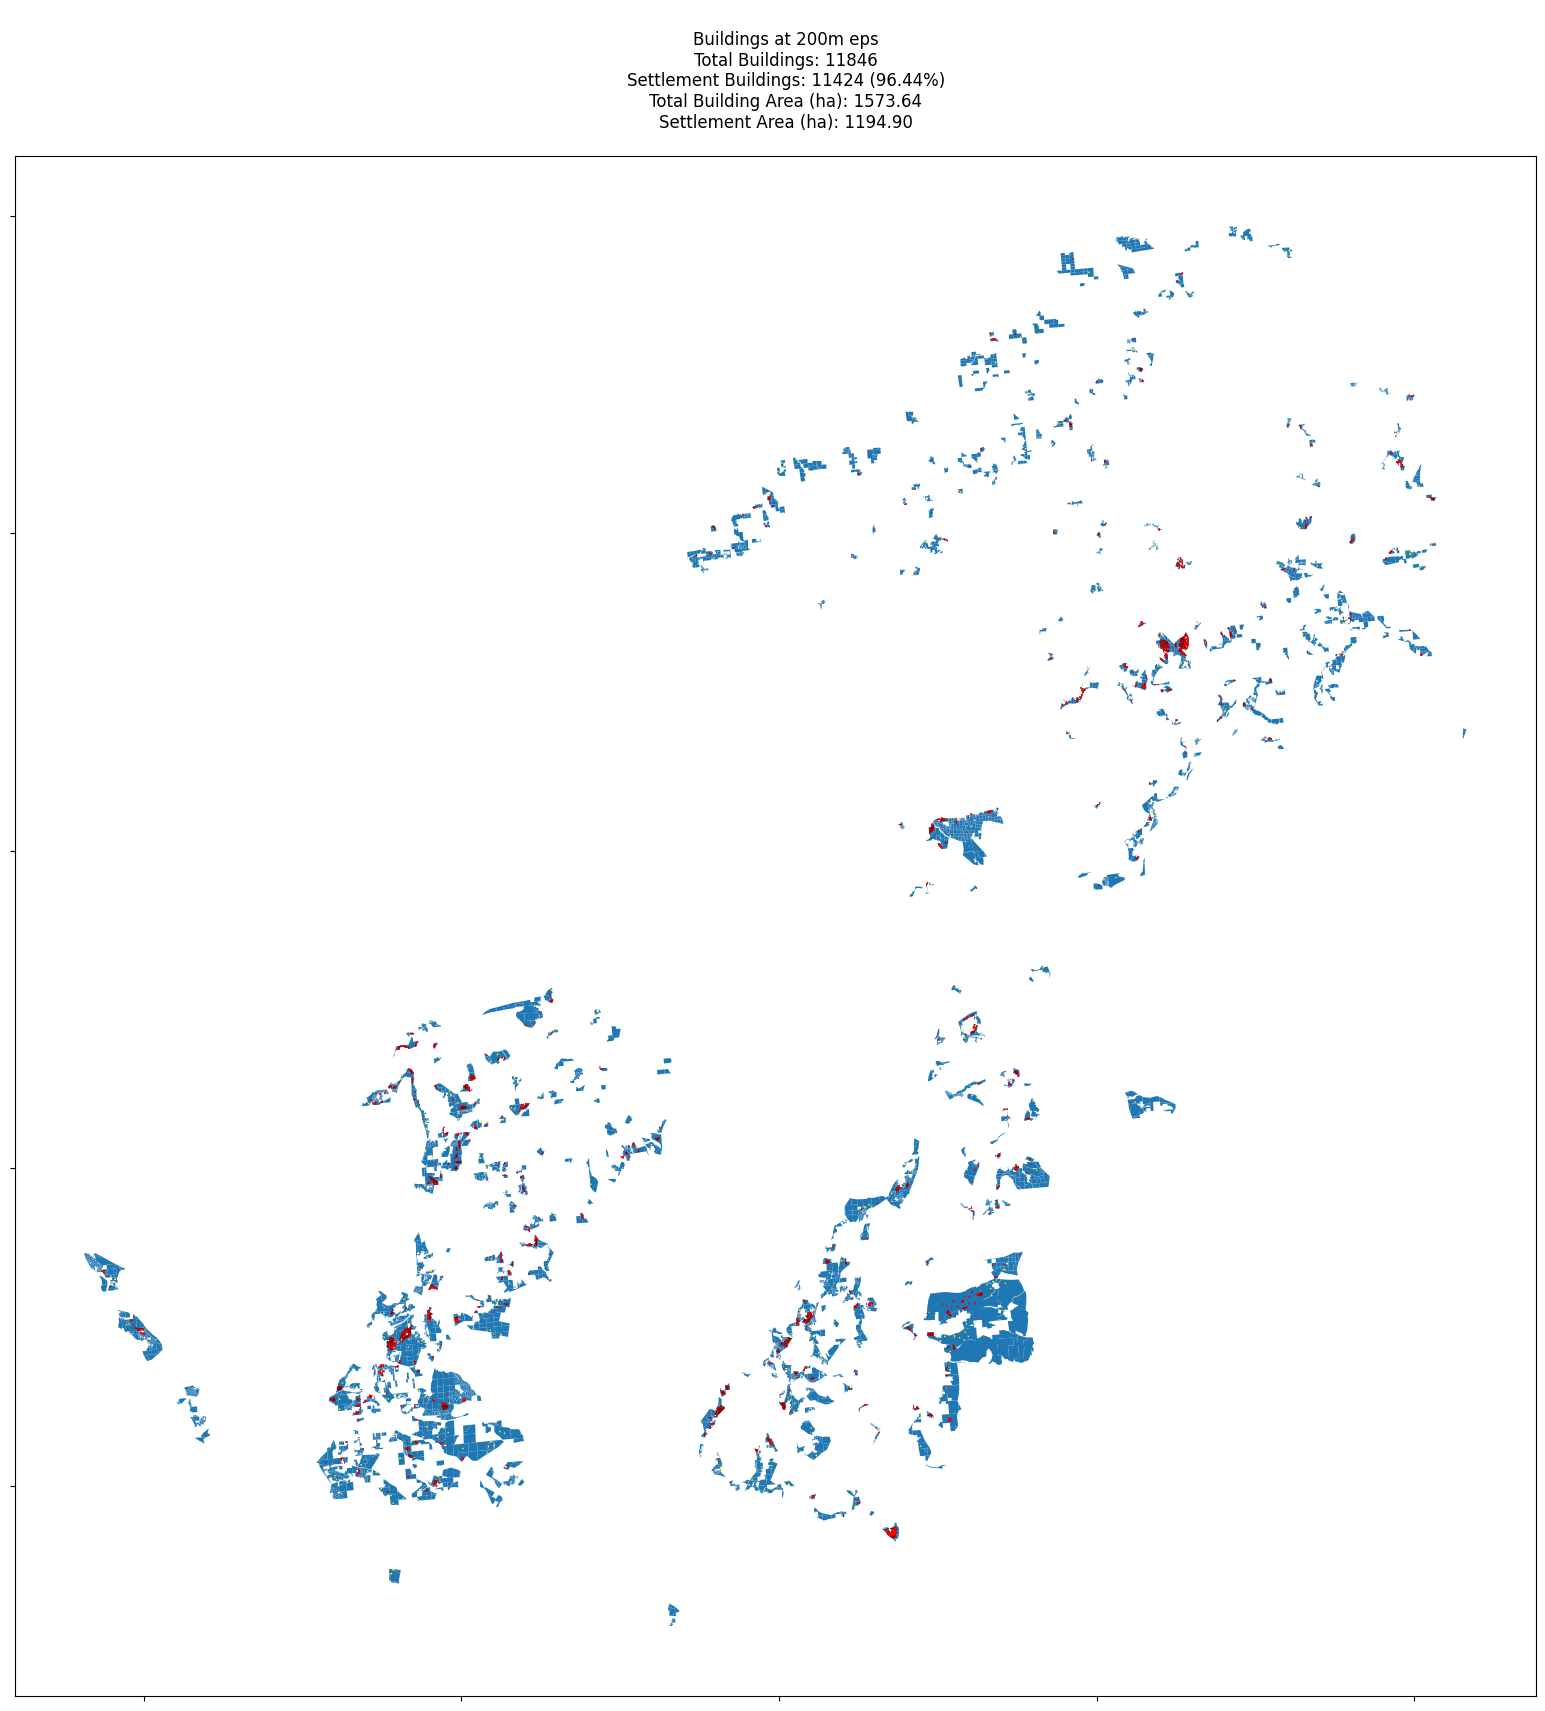

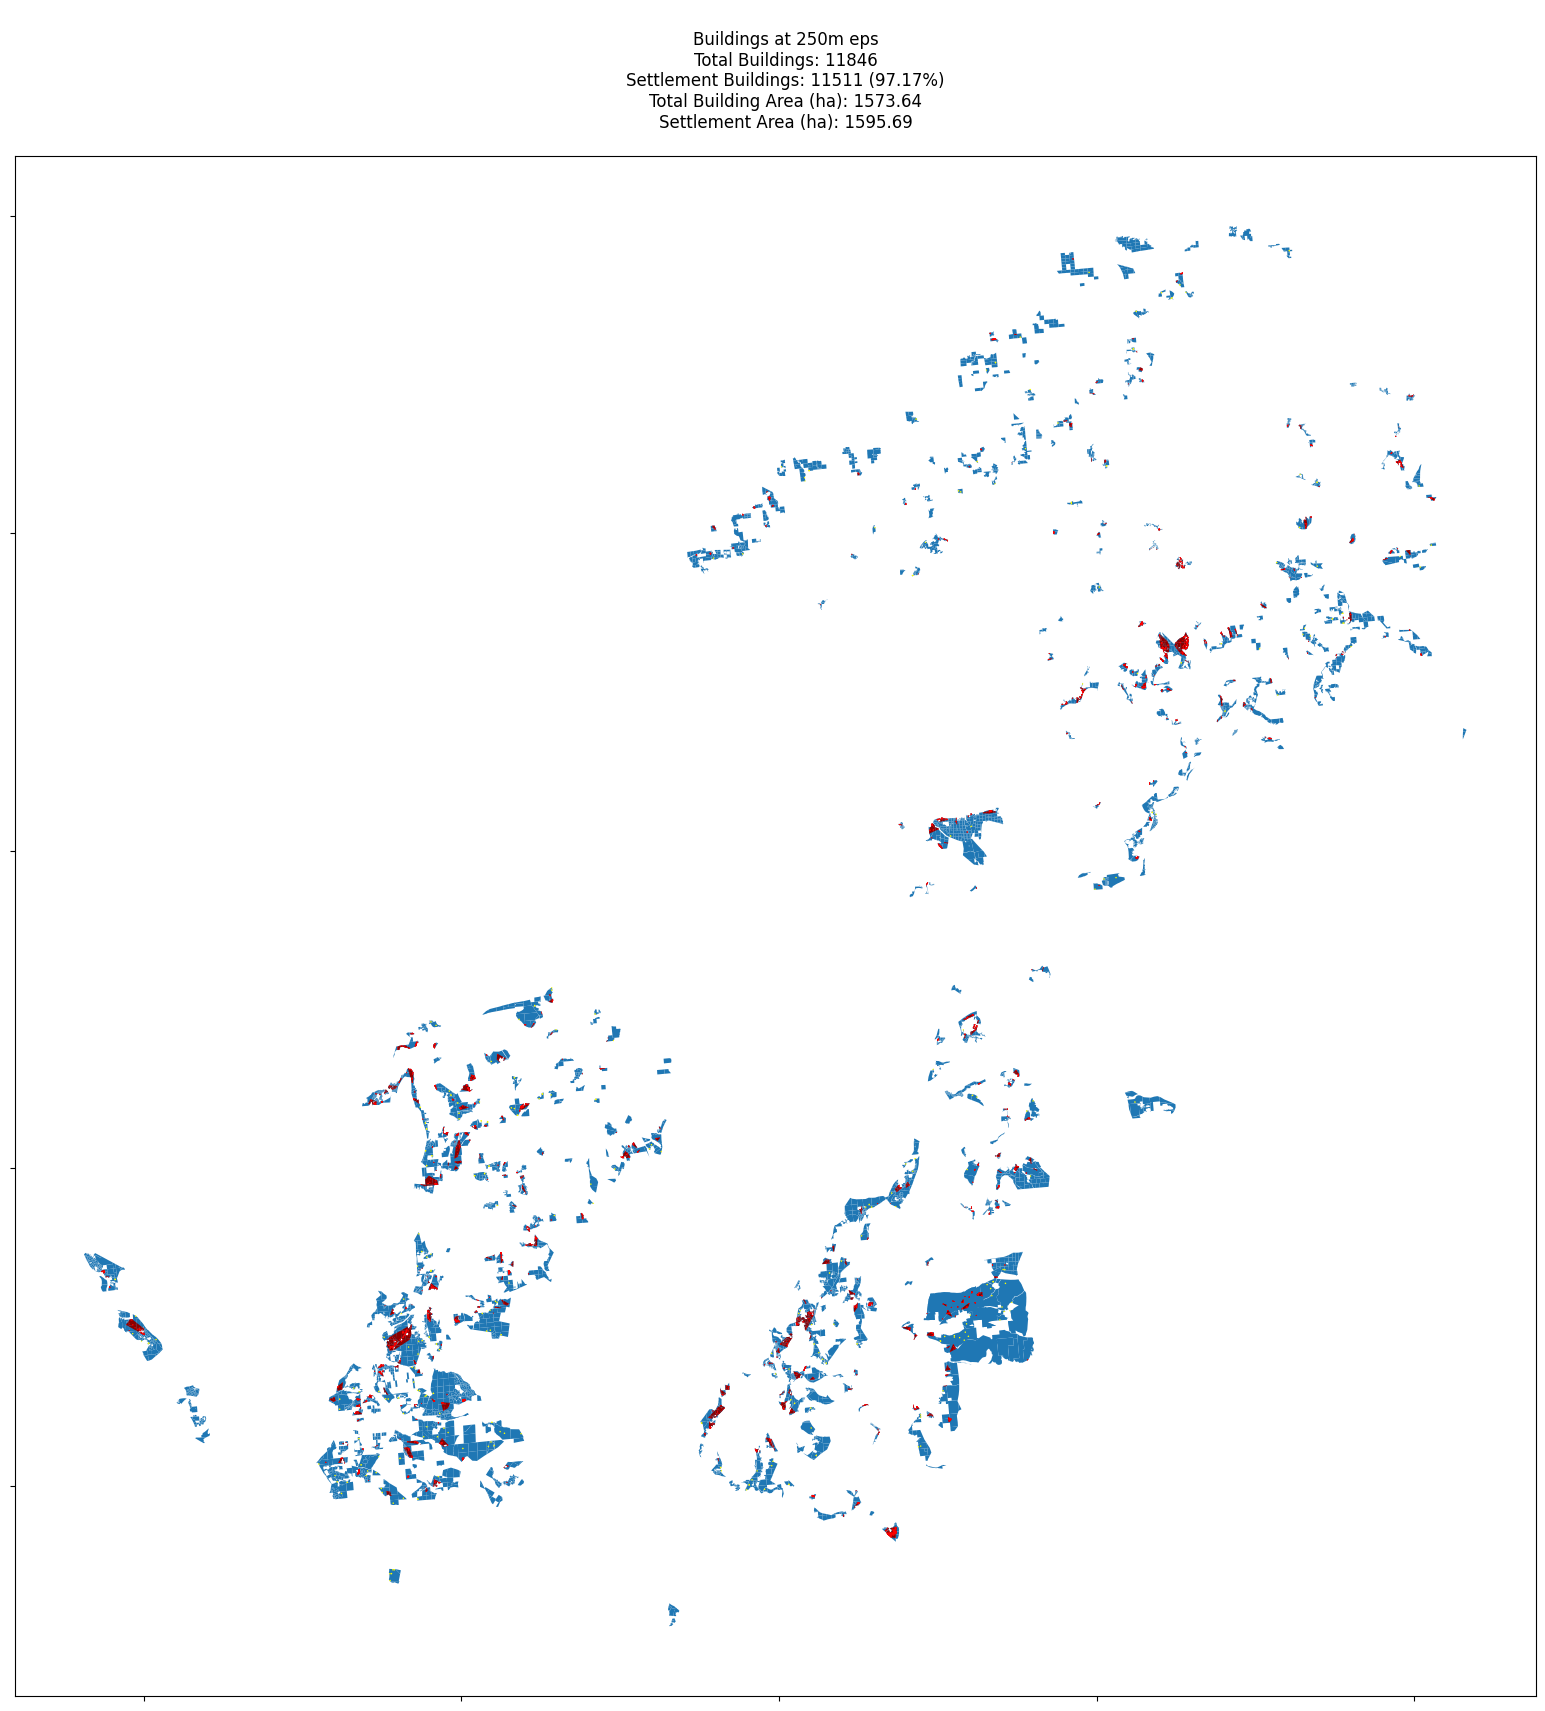

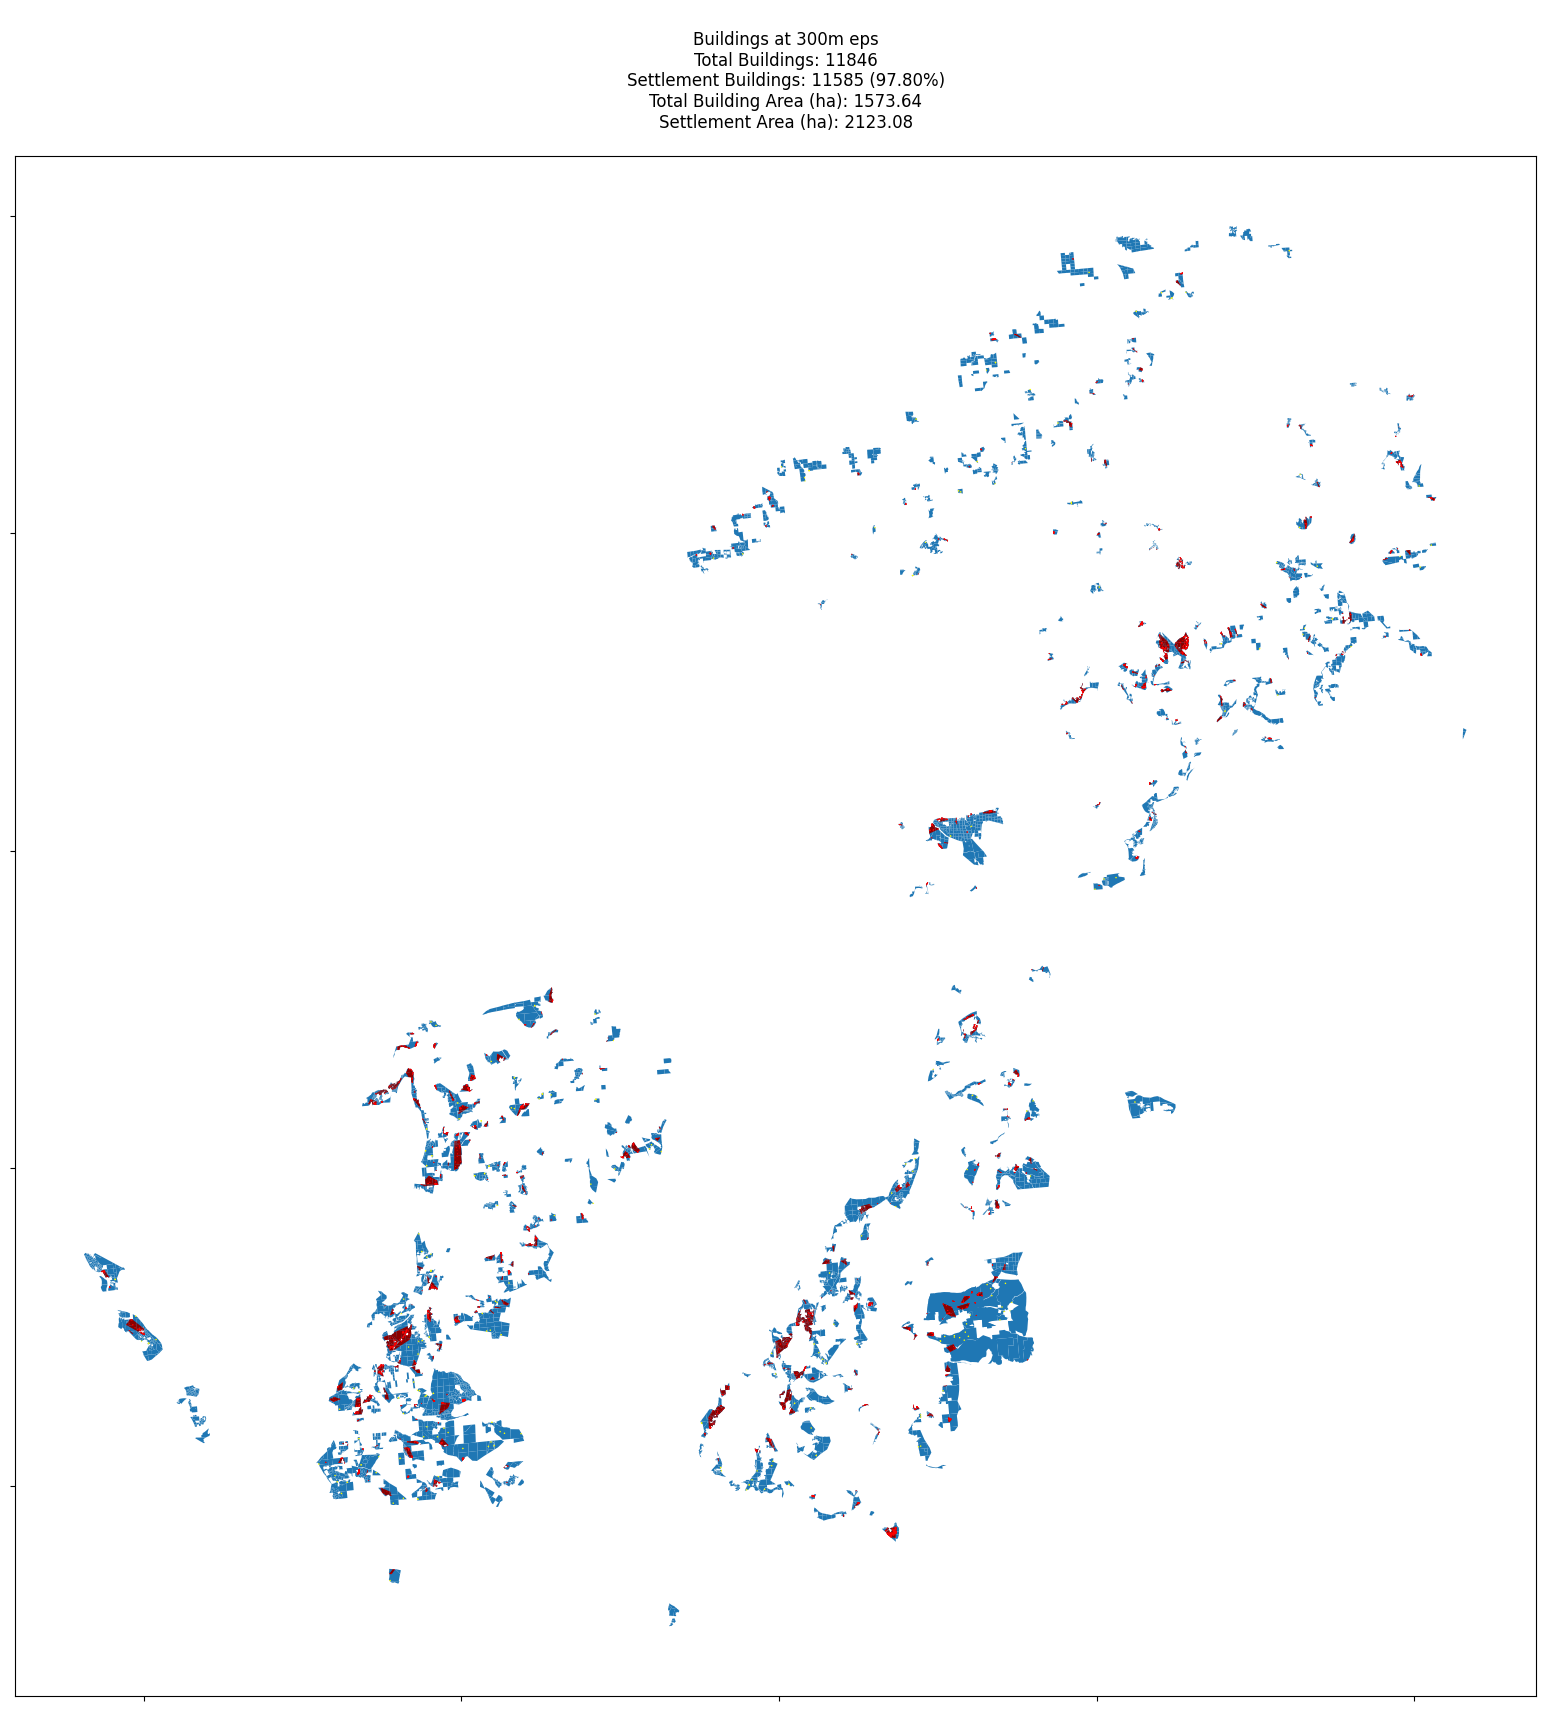

In [20]:
# AUTOMATIC
from sklearn.cluster import DBSCAN

for eps in [200, 250, 300]:
    clusterer = DBSCAN(eps=eps, min_samples=3, n_jobs=-1)
    building_centroids = buildings_overlap_gdf.geometry.centroid
    X = np.array(list(zip(building_centroids.x, building_centroids.y)))
    building_cluster_ids = clusterer.fit_predict(X)
    buildings_overlap_gdf["settlement_id"] = building_cluster_ids

    settlement_buildings_gdf = buildings_overlap_gdf[
        buildings_overlap_gdf["settlement_id"] != -1
    ]
    rogue_buildings_gdf = buildings_overlap_gdf[
        buildings_overlap_gdf["settlement_id"] == -1
    ]

    # get the convex hull of each cluster
    settlements_gdf = settlement_buildings_gdf.dissolve(by="settlement_id").reset_index()
    settlements_gdf = settlements_gdf[["geometry", "settlement_id"]]
    settlements_gdf.geometry = settlements_gdf.convex_hull

    # get cutout of the buffered building shapes that overlap parcels
    settlements_gdf = gpd.overlay(settlements_gdf, gdf, how="intersection")
    settlements_gdf = settlements_gdf[["Khasra Name", "settlement_id", "geometry"]]

    # plot
    ax = gdf.plot(figsize=(20, 20))
    settlements_gdf.plot(ax=ax, color=SETTLEMENT_COLOR)
    settlement_buildings_gdf.plot(ax=ax, color="red")
    rogue_buildings_gdf.buffer(20).plot(ax=ax, color=BUILDING_COLOR)

    # add stats
    total_count = len(buildings_overlap_gdf)
    settlement_count = len(settlement_buildings_gdf)
    perc_settlement_buildings = settlement_count / total_count * 100
    rogue_count = len(rogue_buildings_gdf)
    total_area = buildings_overlap_gdf.area.sum() / 10_000
    settlement_area = settlements_gdf.area.sum() / 10_000
    title = f"""
    Buildings at {eps}m eps
    Total Buildings: {total_count}
    Settlement Buildings: {settlement_count} ({perc_settlement_buildings:.2f}%)
    Total Building Area (ha): {total_area:.2f}
    Settlement Area (ha): {settlement_area:.2f}
    """
    ax.set_title(title, fontsize=12)
    ax.set_xticklabels([])
    ax.set_yticklabels([])

    plt.savefig(
        DISTRICT_MAPS_OUTPUT_DATA_DIR / f"settlements_{eps}.png", dpi=300, bbox_inches='tight'
    )

In [21]:
CHOSEN_EPS = 200
clusterer = DBSCAN(eps=CHOSEN_EPS, min_samples=3, n_jobs=-1)
building_centroids = buildings_overlap_gdf.geometry.centroid
X = np.array(list(zip(building_centroids.x, building_centroids.y)))
building_cluster_ids = clusterer.fit_predict(X)
buildings_overlap_gdf["settlement_id"] = building_cluster_ids

settlement_buildings_gdf = buildings_overlap_gdf[
    buildings_overlap_gdf["settlement_id"] != -1
]
rogue_buildings_gdf = buildings_overlap_gdf[
    buildings_overlap_gdf["settlement_id"] == -1
]

# get the convex hull of each cluster
settlements_gdf = settlement_buildings_gdf.dissolve(by="settlement_id").reset_index()
settlements_gdf = settlements_gdf[["geometry", "settlement_id"]]
settlements_gdf.geometry = settlements_gdf.convex_hull

# get cutout of the buffered building shapes that overlap parcels
settlements_gdf = gpd.overlay(settlements_gdf, gdf, how="intersection")
settlements_gdf = settlements_gdf[["Khasra ID (Unique)", "settlement_id", "geometry"]]

In [22]:
building_counts_df = buildings_overlap_gdf.groupby("Khasra ID (Unique)").size().reset_index(name="Building Count")
building_counts_df

,Khasra ID (Unique),Building Count
0,1 (MRA1421),2
1,1 (MRA29),28
2,1 (MRA30),2
3,1 (MRA696),7
4,1 (SEO2687),1
...,...,...
1741,Unit II (7),1
1742,Unit III (0),2
1743,Unit III (1),1
1744,Unit III (5),3


In [23]:
rogue_buildings_overlap_gdf = rogue_buildings_gdf.dissolve(by="Khasra ID (Unique)").reset_index()
settlement_buildings_overlap_gdf = settlement_buildings_gdf.dissolve(by="Khasra ID (Unique)").reset_index()

In [24]:
rogue_buildings_overlap_gdf["Unavailable Area - Isolated Buildings (ha)"] = rogue_buildings_overlap_gdf.area / 10_000
rogue_buildings_unusable_area_df = rogue_buildings_overlap_gdf[["Khasra ID (Unique)", "Unavailable Area - Isolated Buildings (ha)"]]

In [25]:
settlements_overlap_gdf = settlements_gdf.dissolve(by="Khasra ID (Unique)").reset_index()
settlements_overlap_gdf["Unusable Area - Settlements (ha)"] = settlements_overlap_gdf.area / 10_000
settlements_unusable_area_df = settlements_overlap_gdf[["Khasra ID (Unique)", "Unusable Area - Settlements (ha)"]]

### Landcover (Cropland, Water)

#### Landcover

In [26]:
# for TIFF files
import rasterio
from rasterio.plot import show
from rasterio.features import shapes
from shapely.geometry import shape

In [27]:
def get_landcover_shapes(
    landcover_data,
    transform,
    class_name,
    class_value_lookup_dict,
    raster_crs="4326",
    target_crs="24378",
):
    # Get array values
    class_values = class_value_lookup_dict[class_name]

    # Create mask
    layer_mask = np.isin(landcover_data, class_values)

    # Extract vector shapes and make a GeoDataFrame
    vector_shapes = [
        {"geometry": shape(geom), "properties": {"class": class_name}}
        for geom, class_value in shapes(
            landcover_data, mask=layer_mask, transform=transform
        )
    ]
    shapes_gdf = gpd.GeoDataFrame(vector_shapes, crs=raster_crs)
    shapes_gdf = shapes_gdf.to_crs(target_crs)

    return shapes_gdf

In [28]:
path = "../data/00_raw/landcover/30N_070E_2020.tif"
src = rasterio.open(path)

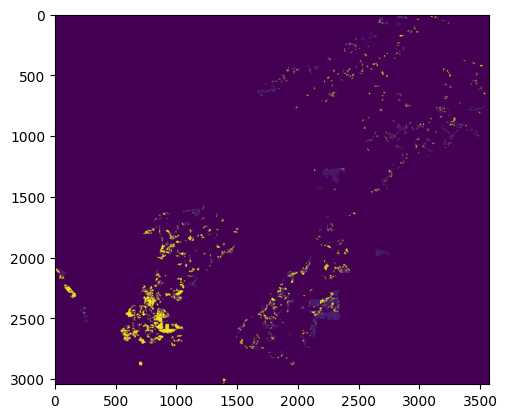

<Axes: >

In [29]:
masked_landcover_data, masked_transform = rasterio.mask.mask(src, [gdf.to_crs(4326).unary_union], crop=True)
masked_landcover_data = np.squeeze(masked_landcover_data)
show(masked_landcover_data)

In [30]:
# load value to landcover type mapping legend
legend_df = pd.read_csv(RAW_DATA_DIR / "landcover" / "legend_processed.csv")
landcover_value_class_dict = legend_df.set_index("map_value")["class_b"].to_dict()

landcover_class_value_dict = {}
for key, value in landcover_value_class_dict.items():
    if value not in landcover_class_value_dict:
        landcover_class_value_dict[value] = [key]
    else:
        landcover_class_value_dict[value].append(key)

#### Cropland

In [31]:
cropland_shapes_gdf = get_landcover_shapes(
    masked_landcover_data,
    masked_transform,
    class_name="Cropland",
    class_value_lookup_dict=landcover_class_value_dict,
    raster_crs=src.crs,
    target_crs=INDIA_PROJECTED_CRS,
)

In [32]:
# get cutout of the water shapes that overlap parcels
cropland_overlap_gdf = gpd.overlay(
    cropland_shapes_gdf, gdf, how="intersection"
)
cropland_overlap_gdf = cropland_overlap_gdf.dissolve(by="Khasra ID (Unique)").reset_index()

In [33]:
cropland_overlap_gdf["Unavailable Area - Cropland (ha)"] = cropland_overlap_gdf.area / 10_000
cropland_unusable_area_df = cropland_overlap_gdf[["Khasra ID (Unique)", "Unavailable Area - Cropland (ha)"]]

#### Water

In [34]:
water_shapes_gdf = get_landcover_shapes(
    masked_landcover_data,
    masked_transform,
    class_name="Open surface water",
    class_value_lookup_dict=landcover_class_value_dict,
    raster_crs=src.crs,
    target_crs=INDIA_PROJECTED_CRS,
)

In [35]:
# get cutout of the water shapes that overlap parcels
water_overlap_gdf = gpd.overlay(
    water_shapes_gdf, gdf, how="intersection"
)
water_overlap_gdf = water_overlap_gdf.dissolve(by="Khasra ID (Unique)").reset_index()

In [36]:
water_overlap_gdf["Unusable Area - Water (ha)"] = water_overlap_gdf.area / 10_000
water_unusable_area_df = water_overlap_gdf[["Khasra ID (Unique)", "Unusable Area - Water (ha)"]]

#### Trees

In [37]:
tree_shapes_gdf = get_landcover_shapes(
    masked_landcover_data,
    masked_transform,
    class_name="Tree cover",
    class_value_lookup_dict=landcover_class_value_dict,
    raster_crs=src.crs,
    target_crs=INDIA_PROJECTED_CRS,
)

In [38]:
# get cutout of the tree shapes that overlap parcels
tree_overlap_gdf = gpd.overlay(
    tree_shapes_gdf, gdf, how="intersection"
)
tree_overlap_gdf = tree_overlap_gdf.dissolve(by="Khasra ID (Unique)").reset_index()

<Axes: >

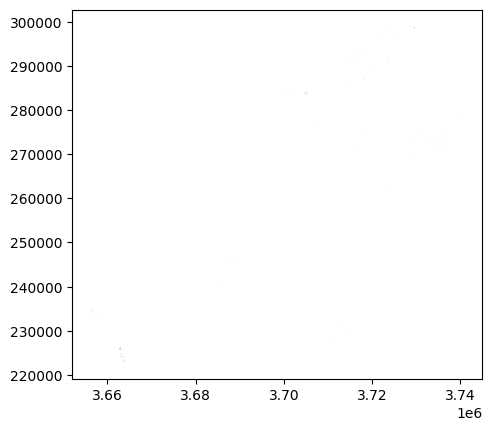

In [39]:
tree_overlap_gdf.plot()

In [40]:
tree_overlap_gdf["Unusable Area - Tree Cover (ha)"] = tree_overlap_gdf.area / 10_000
tree_unusable_area_df = tree_overlap_gdf[["Khasra ID (Unique)", "Unusable Area - Tree Cover (ha)"]]
tree_unusable_area_df

,Khasra ID (Unique),Unusable Area - Tree Cover (ha)
0,1005 (MRA2070),0.000038
1,1017 (MRA2070),0.069124
2,1019 (MRA2070),0.040378
3,1020 (MRA2070),0.670005
4,1026 (MRA2070),0.238136
...,...,...
134,9 (MRA2233),0.069589
135,90 (SEO2429),0.081305
136,96 (SEO2429),0.007616
137,Unit II (7),0.070076


### Slope

Source: https://bhuvan-app3.nrsc.gov.in/data/download/index.php

ISRO CartoDEM Version-3 R1, 30m resolution. The Cartosat-1 Digital Elevation Model (CartoDEM) is a National DEM developed by the Indian Space Research Organization (ISRO). It is derived from the Cartosat-1 stereo payload launched in May 2005. PDFs in folder.


When using the `pydem` package, angles are outputted in radians so we have to convert to degrees. Aspect is measured from the x-axis and counter-clockwise, making East 0 and North 90deg.

We choose between 45 and 135 since north is at 90! 0 is east, and rotates counter-clockwise.

https://grass.osgeo.org/grass-stable/manuals/r.slope.aspect.html

#### Load slope data

In [41]:
from pydem.dem_processing import DEMProcessor

/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/pydem/dem_processing.py:76: RuntimeWarning: Cython functions are not compiled. UCA cannot be calculated. Consider compiling cython functions using: python setup.py build_ext --inplace
  warnings.warn("Cython functions are not compiled. UCA cannot be calculated."


In [42]:
import xdem

In [43]:
def get_steep_shapes(dem_filename):
    print(f"Processing {dem_filename}...")
    dem_filepath = RAW_DATA_DIR / "elevation" / f"{dem_filename}.tif"
    dem_proc = DEMProcessor(dem_filepath)
    transform = dem_proc.transform  # need this transform later

    try:
        print("Trying to load pre-calculated slopes and aspects...")
        slope_pydem = np.load(
            RAW_DATA_DIR / "elevation" / f"{dem_filename}_magnitude.npy"
        )
        aspect_pydem = np.load(
            RAW_DATA_DIR / "elevation" / f"{dem_filename}_aspect.npy"
        )
    except FileNotFoundError:
        print("Pre-calculated file not found. Calculating slopes and aspects...")
        slope_pydem, aspect_pydem = dem_proc.calc_slopes_directions()
        np.save(
            RAW_DATA_DIR / "elevation" / f"{dem_filename}_magnitude.npy", slope_pydem
        )
        np.save(RAW_DATA_DIR / "elevation" / f"{dem_filename}_aspect.npy", aspect_pydem)
    # convert from radians to degrees
    aspect = np.degrees(aspect_pydem)
    slope = np.degrees(slope_pydem)

    # Display slope and aspect
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(8, 6))
    # slope vis
    ax1.imshow(slope)
    ax1.set_title(f"{dem_filename} - Slope")
    ax2.hist(slope.flatten(), bins=100)
    ax2.set_title("Slope Histogram")
    # aspect vis
    ax3.imshow(aspect)
    ax3.set_title(f"{dem_filename} - Aspect")
    ax4.hist(aspect.flatten(), bins=100)
    ax4.set_title("Aspect Histogram")
    plt.tight_layout()
    plt.show()

    # set all values below 0 to 0
    aspect[aspect < 0] = 0
    slope[slope < 0] = 0

    # filter to only aspects that are between NE and NW azimuth around north and 7 degrees or more
    slope_mask = np.where((aspect >= 45) & (aspect < 135) & (slope > 7), True, False)

    # Plot the mask with a binary colormap and correct axes
    x_min = transform[2]
    x_max = x_min + transform[0] * slope_mask.shape[1]
    y_max = transform[5]
    y_min = y_max + transform[4] * slope_mask.shape[0]
    plt.imshow(slope_mask, extent=[x_min, x_max, y_min, y_max], cmap="binary")
    plt.colorbar(label="Aspect Mask", ax=ax)
    plt.title("Aspect Mask")
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.show()

    # Extract vector shapes and make a GeoDataFrame
    print("Extracting vector shapes...")
    vector_shapes = [
        {"geometry": shape(geom)}
        for geom, class_value in shapes(slope, mask=slope_mask, transform=transform)
    ]
    slope_shapes_gdf = gpd.GeoDataFrame(vector_shapes)
    slope_shapes_gdf = slope_shapes_gdf.set_crs(4326).to_crs(INDIA_PROJECTED_CRS)

    return slope_shapes_gdf

Processing P5_PAN_CD_N25_000_E077_000_DEM_30m...
No 'ELLIPSOID' key in wkt: list index out of range
Trying to load pre-calculated slopes and aspects...


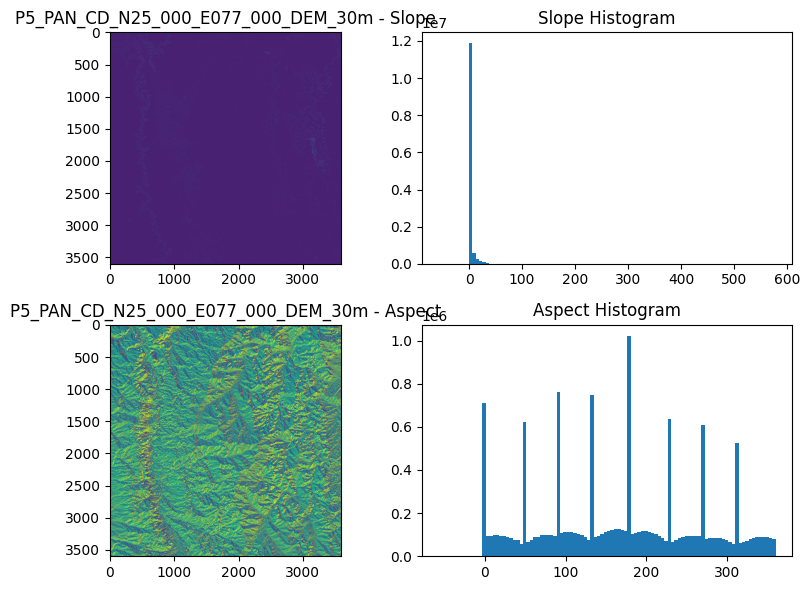

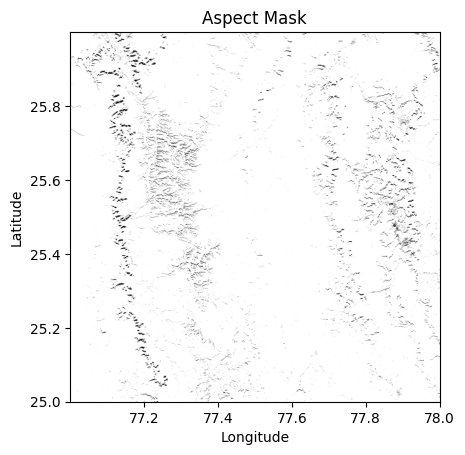

Extracting vector shapes...
Processing P5_PAN_CD_N26_000_E077_000_DEM_30m...
No 'ELLIPSOID' key in wkt: list index out of range
Trying to load pre-calculated slopes and aspects...


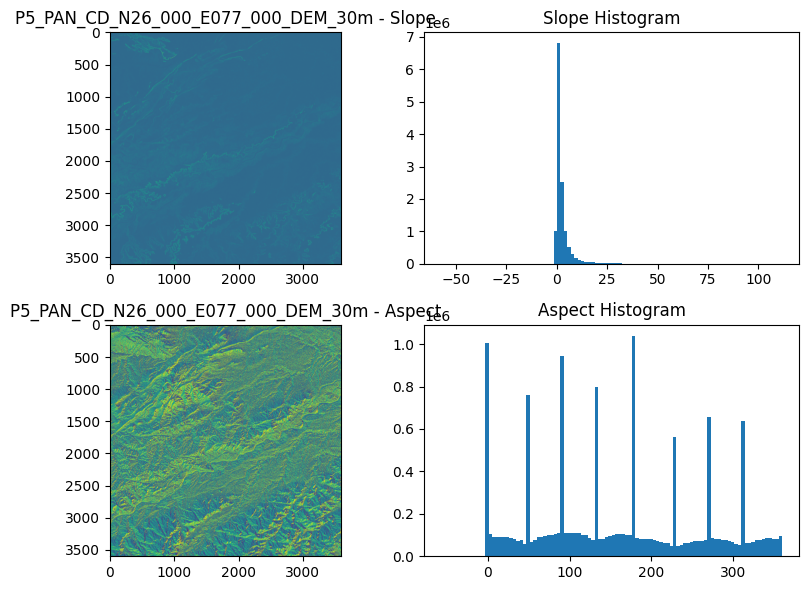

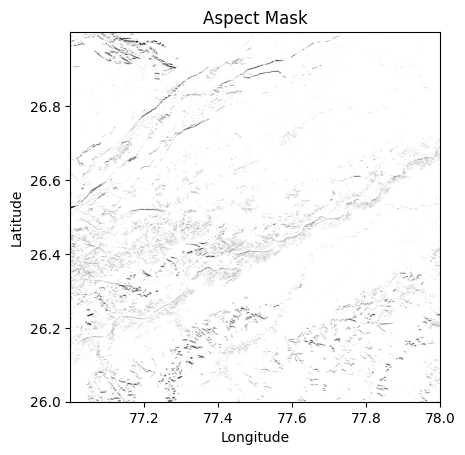

Extracting vector shapes...


In [44]:
dem_filenames = ["P5_PAN_CD_N25_000_E077_000_DEM_30m", "P5_PAN_CD_N26_000_E077_000_DEM_30m"]

steep_shapes_gdf_list = []
for dem_filename in dem_filenames:
    steep_shapes_gdf = get_steep_shapes(dem_filename)
    steep_shapes_gdf_list.append(steep_shapes_gdf)

In [45]:
slope_shapes_gdf = pd.concat(steep_shapes_gdf_list, ignore_index=True)

In [46]:
slope_overlap_gdf = gpd.overlay(
    slope_shapes_gdf, gdf, how="intersection", keep_geom_type=False
)
slope_overlap_gdf = slope_overlap_gdf.dissolve(by="Khasra ID (Unique)").reset_index()

<Axes: >

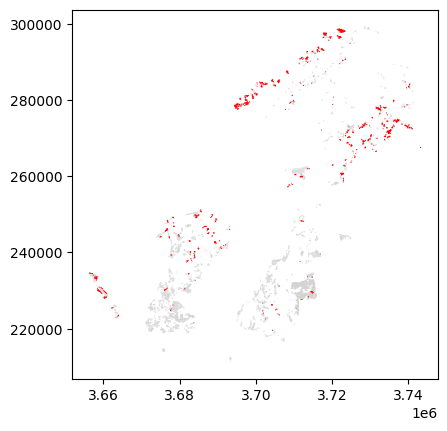

In [47]:
ax = gdf.plot(color="lightgrey")
slope_overlap_gdf.buffer(100).plot(ax=ax, color="red")

In [48]:
slope_overlap_gdf["Unavailable Area - Slope (ha)"] = slope_overlap_gdf.area / 10_000
slope_unusable_area_df = slope_overlap_gdf[["Khasra ID (Unique)", "Unavailable Area - Slope (ha)"]]

## Merge in unusable layers
to find out which should be discarded and which taken forward

In [49]:
parcel_gdf_for_unusable_area = gdf.copy()
selected_Name_list = parcel_gdf_for_unusable_area["Khasra ID (Unique)"].unique()
selected_foldername = "Layered"

#### Plots

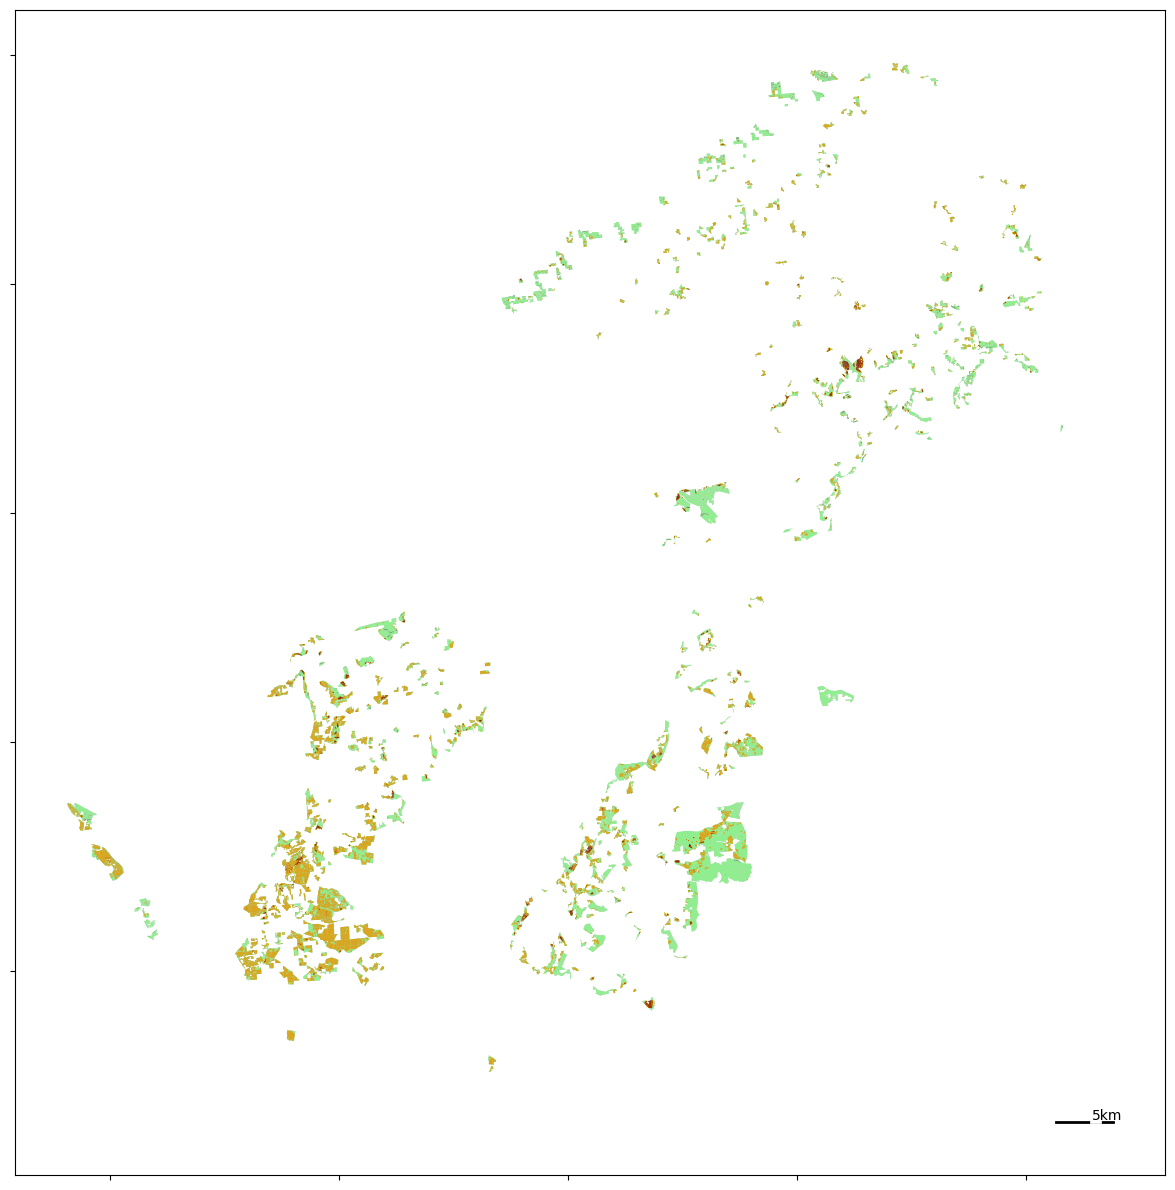

In [50]:
FOLDER_PATH = OUTPUT_DATA_DIR / LOCATION
FOLDER_PATH.mkdir(parents=True, exist_ok=True)

# add colored outline based on Name

ax = gdf.plot(figsize=(12, 12), color="black", alpha=0.2)
parcel_gdf_for_unusable_area.plot(
    ax=ax,
    color=BACKGROUND_COLOR,
    label="Original Khasras",
)
ax.set_xticklabels([])
ax.set_yticklabels([])

# add a 1km line to show scale on the plot
xmin, xmax = ax.get_xlim()
ymin, ymax = ax.get_ylim()
ax.plot([xmax - 5000, xmax], [ymin, ymin], color="white", linewidth=5, linestyle="-")
ax.plot([xmax - 5000, xmax], [ymin, ymin], color="black", linewidth=2, linestyle="-")
ax.plot(
    [xmax - 1600, xmax - 1400],
    [ymin + 250, ymin + 250],
    color="white",
    linewidth=7,
    linestyle="-",
)
ax.text(xmax - 500, ymin + 150, "5km", fontsize=10, ha="center")

buildings_overlap_gdf[
    buildings_overlap_gdf["Khasra ID (Unique)"].isin(selected_Name_list)
].plot(ax=ax, color=BUILDING_COLOR, label="Buildings + 25m buffer")

settlements_overlap_gdf[
    settlements_overlap_gdf["Khasra ID (Unique)"].isin(selected_Name_list)
].plot(ax=ax, color=SETTLEMENT_COLOR, alpha=0.8, label="Settlements")

water_overlap_gdf[water_overlap_gdf["Khasra ID (Unique)"].isin(selected_Name_list)].plot(
    ax=ax, color=WATER_COLOR, label="Water"
)

cropland_overlap_gdf[
    cropland_overlap_gdf["Khasra ID (Unique)"].isin(selected_Name_list)
].plot(ax=ax, color=CROPLAND_COLOR, label="Cropland")

slope_overlap_gdf[slope_overlap_gdf["Khasra ID (Unique)"].isin(selected_Name_list)].plot(
    ax=ax, color=SLOPE_COLOR, alpha=0.8, label="Slopes > 7 deg"
)

plt.tight_layout()
LAYERS = "Buildings, Settlements, Water, Cropland, Slopes"
plt.savefig(
    DISTRICT_MAPS_OUTPUT_DATA_DIR / "clusters_w_layers.png",
    dpi=300,
    bbox_inches="tight",
)

In [51]:
# ### THIS HAS THE MOST UPDATED PLOTTING CODE - 2nd April 2025
# import matplotlib.patches as mpatches

# for CHOSEN_PARCEL_ID in selected_Name_list:
#     FOLDER_PATH = (
#         OUTPUT_DATA_DIR
#         / LOCATION
#         / "Individual Parcels"
#         / selected_foldername
#         / CHOSEN_PARCEL_ID
#     )
#     FOLDER_PATH.mkdir(parents=True, exist_ok=True)

#     # # 1. Histogram of intra-distances
#     # subset_intra_distances_df = intra_distances_df[
#     #     intra_distances_df["Khasra ID (Unique)"] == CHOSEN_PARCEL_ID
#     # ]

#     # f, ax = plt.subplots(1, 1, figsize=(8, 6))
#     # subset_intra_distances_df["raw_distances"].hist(
#     #     ax=ax, bins=25, color="skyblue", edgecolor="black"
#     # )

#     # # add lines for average and 75% percentile
#     # avg_distance = subset_intra_distances_df[
#     #     "Inter-Khasra Distance Average (m)"
#     # ].values[0]
#     # percentile_75th_distance = subset_intra_distances_df[
#     #     "Inter-Khasra Distance 75th Percentile (m)"
#     # ].values[0]

#     # ax.axvline(
#     #     avg_distance,
#     #     color=BACKGROUND_COLOR,
#     #     linestyle="--",
#     #     label=f"Average: {avg_distance}m",
#     # )
#     # ax.axvline(
#     #     percentile_75th_distance,
#     #     color="darkgreen",
#     #     linestyle="--",
#     #     label=f"75th Percentile: {percentile_75th_distance}m",
#     # )

#     # ax.legend()
#     # # ax.set_title(f"Inter-Khasra Distances within {CHOSEN_PARCEL_ID}", fontsize=14)
#     # ax.set_xlabel("Distance to Neighbouring Khasra", fontsize=12)
#     # ax.set_ylabel("Frequency", fontsize=12)
#     # ax.grid(True, linestyle="--", alpha=0.7)

#     # plt.tight_layout()
#     # plt.savefig(
#     #     FOLDER_PATH / "intra_distances_histogram.png", dpi=300, bbox_inches="tight"
#     # )
#     # plt.show()

#     # 2. Khasra-level plot
#     ax = gdf[gdf["Khasra ID (Unique)"] == CHOSEN_PARCEL_ID].plot(
#         column="khasra_id",
#         cmap=ListedColormap(
#             generate_colormap(len(gdf["khasra_id"].unique()))
#         ),
#         figsize=(8, 8),
#     )

#     ax.set_xticklabels([])
#     ax.set_yticklabels([])

#     # add a 1km line to show scale on the plot
#     xmin, xmax = ax.get_xlim()
#     ymin, ymax = ax.get_ylim()
#     ax.plot(
#         [xmax - 1000, xmax], [ymin, ymin], color="white", linewidth=5, linestyle="-"
#     )
#     ax.plot(
#         [xmax - 1000, xmax], [ymin, ymin], color="black", linewidth=2, linestyle="-"
#     )
#     ax.plot(
#         [xmax - 550, xmax - 450],
#         [ymin + 50, ymin + 50],
#         color="white",
#         linewidth=7,
#         linestyle="-",
#     )
#     ax.text(xmax - 500, ymin + 50, "1km", fontsize=6, ha="center")

#     plt.tight_layout()
#     plt.savefig(FOLDER_PATH / "khasras.png", dpi=300, bbox_inches="tight")

#     # 3. Parcel + Layers plots

#     handles = []
#     for i in range(5):
#         ax = gdf[
#             gdf["Khasra ID (Unique)"] == CHOSEN_PARCEL_ID
#         ].plot(
#             color=BACKGROUND_COLOR,
#             label="Original Parcel",
#             figsize=(11, 11),
#         )
#         handles.append(
#             mpatches.Patch(
#                 color=BACKGROUND_COLOR,
#                 label="Usable and Available Area",
#             )
#         )
#         ax.set_xticklabels([])
#         ax.set_yticklabels([])
#         ax.set_title(f"{CHOSEN_PARCEL_ID}", fontsize=24)
#         # add a 1km line to show scale on the plot
#         xmin, xmax = ax.get_xlim()
#         ymin, ymax = ax.get_ylim()
#         ax.plot(
#             [xmax - 1000, xmax], [ymin, ymin], color="white", linewidth=5, linestyle="-"
#         )
#         ax.plot(
#             [xmax - 1000, xmax], [ymin, ymin], color="black", linewidth=2, linestyle="-"
#         )
#         ax.plot(
#             [xmax - 550, xmax - 450],
#             [ymin + 30, ymin + 30],
#             color="white",
#             linewidth=7,
#             linestyle="-",
#         )
#         ax.text(xmax - 500, ymin + 30, "1km", fontsize=12, ha="center")

#         # add buildings as first layer
#         buildings_overlap_gdf[
#             buildings_overlap_gdf["Khasra ID (Unique)"] == CHOSEN_PARCEL_ID
#         ].plot(ax=ax, color=BUILDING_COLOR, label="Buildings + 25m buffer")
#         LAYERS = "Buildings"
#         handles.append(
#             mpatches.Patch(color=BUILDING_COLOR, label="Buildings + 25m buffer")
#         )

#         if i >= 1:
#             settlements_overlap_gdf[
#                 settlements_overlap_gdf["Khasra ID (Unique)"] == CHOSEN_PARCEL_ID
#             ].plot(ax=ax, color=SETTLEMENT_COLOR, alpha=0.8, label="Settlements")
#             LAYERS = "Buildings, Settlements"
#             handles.append(mpatches.Patch(color=SETTLEMENT_COLOR, label="Settlements"))

#         if i >= 2:
#             water_overlap_gdf[water_overlap_gdf["Khasra ID (Unique)"] == CHOSEN_PARCEL_ID].plot(
#                 ax=ax, color=WATER_COLOR, label="Water"
#             )
#             LAYERS = "Buildings, Settlements, Water"
#             handles.append(mpatches.Patch(color=WATER_COLOR, label="Water"))

#         if i >= 3:
#             cropland_overlap_gdf[
#                 cropland_overlap_gdf["Khasra ID (Unique)"] == CHOSEN_PARCEL_ID
#             ].plot(ax=ax, color=CROPLAND_COLOR, label="Cropland")
#             LAYERS = "Buildings, Settlements, Water, Cropland"
#             handles.append(mpatches.Patch(color=CROPLAND_COLOR, label="Cropland"))

#         if i >= 4:
#             slope_overlap_gdf[slope_overlap_gdf["Khasra ID (Unique)"] == CHOSEN_PARCEL_ID].plot(
#                 ax=ax, color=SLOPE_COLOR, alpha=0.8, label="Slopes > 7 deg"
#             )
#             LAYERS = "Buildings, Settlements, Water, Cropland, Slopes"
#             handles.append(
#                 mpatches.Patch(color=SLOPE_COLOR, label="Slope > 7° between NE and NW")
#             )

#         ax.legend(handles=handles, loc="upper left")
#         plt.tight_layout()
#         plt.savefig(
#             FOLDER_PATH / f"Layers - {LAYERS}.png", dpi=300, bbox_inches="tight"
#         )
#         handles = []

#### Calculate Areas

##### Cut out unusable

In [52]:
parcel_gdf_for_unusable_area["Original Area (ha)"] = parcel_gdf_for_unusable_area["geometry"].area / 10000

In [53]:
output_parcel_gdf = parcel_gdf_for_unusable_area.copy()

# cut out water
output_parcel_gdf = gpd.overlay(
    output_parcel_gdf,
    water_overlap_gdf,
    how="difference",
    keep_geom_type=False,
)

# cut out settlements
output_parcel_gdf = gpd.overlay(
    output_parcel_gdf,
    settlements_overlap_gdf,
    how="difference",
    keep_geom_type=False,
)

In [54]:
output_parcel_gdf = clean_geometry(output_parcel_gdf)

In [55]:
# make usable area var so we can put unusable columns first, then usable ones
usable_area_series = output_parcel_gdf.area / 10_000
# unusable area
output_parcel_gdf["Unusable Area (ha)"] = (
    output_parcel_gdf["Original Area (ha)"] - usable_area_series
)
# usable area
output_parcel_gdf["Usable Area (ha)"] = usable_area_series

In [56]:
output_parcel_gdf

,Khasra Name,Description,source,Patch Name,geometry,Khasra ID (Unique),Original Area (ha),Unusable Area (ha),Usable Area (ha)
0,104,Unknown Area Type<BR><BR><B>patch_name</B> = M...,joura,MRA2,"POLYGON ((3704161.237 225934.951, 3704160.543 ...",104 (MRA2),0.474031,0.000000,0.474031
1,106,Unknown Area Type<BR><BR><B>patch_name</B> = M...,joura,MRA2,"POLYGON ((3704076.156 226380.086, 3704074.817 ...",106 (MRA2),0.171199,0.000000,0.171199
2,99,Unknown Area Type<BR><BR><B>patch_name</B> = M...,joura,MRA2,"POLYGON ((3704567.321 226137.773, 3704571.737 ...",99 (MRA2),0.337680,0.336832,0.000848
3,101,Unknown Area Type<BR><BR><B>patch_name</B> = M...,joura,MRA2,"MULTIPOLYGON (((3704432.323 226046.927, 370443...",101 (MRA2),3.912045,1.293615,2.618430
4,103,Unknown Area Type<BR><BR><B>patch_name</B> = M...,joura,MRA2,"POLYGON ((3704337.591 226006.568, 3704339.593 ...",103 (MRA2),5.423501,0.032851,5.390651
...,...,...,...,...,...,...,...,...,...
8598,Unit III,"<html xmlns:fo=""http://www.w3.org/1999/XSL/For...",solar_park_boundary,6,"POLYGON ((3713862.974 232838.948, 3713903.017 ...",Unit III (6),5.831037,0.000000,5.831037
8599,Unit II,"<html xmlns:fo=""http://www.w3.org/1999/XSL/For...",solar_park_boundary,7,"POLYGON ((3713103.712 231242.811, 3713094.107 ...",Unit II (7),99.140329,0.000000,99.140329
8600,Unit I,"<html xmlns:fo=""http://www.w3.org/1999/XSL/For...",solar_park_boundary,8,"POLYGON ((3712591.230 231556.279, 3712591.695 ...",Unit I (8),147.992311,9.394764,138.597547
8601,Unit IV,"<html xmlns:fo=""http://www.w3.org/1999/XSL/For...",solar_park_boundary,9,"MULTIPOLYGON (((3711120.435 228726.818, 371126...",Unit IV (9),338.194298,4.580218,333.614080


In [57]:
save_shapefiles(
    output_parcel_gdf.to_crs(epsg=4326),
    OUTPUT_DATA_DIR / LOCATION / "Khasra Shapefiles",
    "khasras_usable",
    formats=["parquet", "kml", "csv"],
)

##### Cut out unavailable

In [58]:
# cut out cropland
output_parcel_gdf = gpd.overlay(
    output_parcel_gdf,
    cropland_overlap_gdf,
    how="difference",
    keep_geom_type=False,
)
output_parcel_gdf = clean_geometry(output_parcel_gdf)

# cut out rogue buildings
output_parcel_gdf = gpd.overlay(
    output_parcel_gdf,
    rogue_buildings_overlap_gdf,
    how="difference",
    keep_geom_type=False,
)
output_parcel_gdf = clean_geometry(output_parcel_gdf)

# cut out slopes
output_parcel_gdf = gpd.overlay(
    output_parcel_gdf,
    slope_overlap_gdf,
    how="difference",
    keep_geom_type=False,
)
output_parcel_gdf = clean_geometry(output_parcel_gdf)

In [59]:
output_parcel_gdf["Usable and Available Area (ha)"] = output_parcel_gdf.area / 10_000
output_parcel_gdf["Usable but Unavailable Area (ha)"] = (
    output_parcel_gdf["Usable Area (ha)"]
    - output_parcel_gdf["Usable and Available Area (ha)"]
)

In [60]:
# percentages
output_parcel_gdf["Unusable Area (%)"] = (
    output_parcel_gdf["Unusable Area (ha)"]
    / output_parcel_gdf["Original Area (ha)"]
    * 100
)
output_parcel_gdf["Usable Area (%)"] = (
    output_parcel_gdf["Usable Area (ha)"]
    / output_parcel_gdf["Original Area (ha)"]
    * 100
)
output_parcel_gdf["Usable and Available Area (%)"] = (
    output_parcel_gdf["Usable and Available Area (ha)"]
    / output_parcel_gdf["Original Area (ha)"]
    * 100
)
output_parcel_gdf["Usable but Unavailable Area (%)"] = (
    output_parcel_gdf["Usable but Unavailable Area (ha)"]
    / output_parcel_gdf["Original Area (ha)"]
    * 100
)

In [61]:
# add unusable areas
all_unusable_area_cols_df = settlements_unusable_area_df.merge(rogue_buildings_unusable_area_df, on="Khasra ID (Unique)", how="outer").fillna(0)
all_unusable_area_cols_df = all_unusable_area_cols_df.merge(water_unusable_area_df, on="Khasra ID (Unique)", how="outer").fillna(0)
all_unusable_area_cols_df = all_unusable_area_cols_df.merge(cropland_unusable_area_df, on="Khasra ID (Unique)", how="outer").fillna(0)
all_unusable_area_cols_df = all_unusable_area_cols_df.merge(slope_unusable_area_df, on="Khasra ID (Unique)", how="outer").fillna(0)
all_unusable_area_cols_df = all_unusable_area_cols_df.merge(building_counts_df, on="Khasra ID (Unique)", how="outer").fillna(0)
output_parcel_gdf = output_parcel_gdf.merge(all_unusable_area_cols_df, on="Khasra ID (Unique)", how="left").fillna(0)

In [62]:
output_parcel_gdf.fillna(0, inplace=True)

In [63]:
save_shapefiles(
    output_parcel_gdf.to_crs(epsg=4326),
    OUTPUT_DATA_DIR / LOCATION / "Khasra Shapefiles",
    "khasras_usable_available",
    formats=["parquet", "kml", "csv"],
)

## Save individual layers

In [64]:
# save all unusable layes as separate KML files

# cropland
save_shapefiles(
    cropland_overlap_gdf.loc[
        cropland_overlap_gdf["Khasra ID (Unique)"].isin(selected_Name_list),
        [
            "Khasra ID (Unique)",
            "geometry",
            "Unavailable Area - Cropland (ha)",
        ],
    ].to_crs(epsg=4326),
    OUTPUT_DATA_DIR / LOCATION / "Unusable Layers",
    "cropland",
    formats=["kml"],
)


# water
save_shapefiles(
    water_overlap_gdf.loc[
        water_overlap_gdf["Khasra ID (Unique)"].isin(selected_Name_list),
        [
            "Khasra ID (Unique)",
            "geometry",
            "Unusable Area - Water (ha)",
        ],
    ].to_crs(epsg=4326),
    OUTPUT_DATA_DIR / LOCATION / "Unusable Layers",
    "water",
    formats=["kml"],
)

# settlements
save_shapefiles(
    settlements_overlap_gdf.loc[
        settlements_overlap_gdf["Khasra ID (Unique)"].isin(selected_Name_list),
        [
            "Khasra ID (Unique)",
            "geometry",
            "Unusable Area - Settlements (ha)",
        ],
    ].to_crs(epsg=4326),
    OUTPUT_DATA_DIR / LOCATION / "Unusable Layers",
    "settlements",
    formats=["kml"],
)

# rogue buildings
save_shapefiles(
    rogue_buildings_overlap_gdf.loc[
        rogue_buildings_overlap_gdf["Khasra ID (Unique)"].isin(selected_Name_list),
        [
            "Khasra ID (Unique)",
            "geometry",
            "Unavailable Area - Isolated Buildings (ha)",
        ],
    ].to_crs(epsg=4326),
    OUTPUT_DATA_DIR / LOCATION / "Unusable Layers",
    "rogue_buildings",
    formats=["kml"],
)

# slopes
save_shapefiles(
    slope_overlap_gdf.loc[
        slope_overlap_gdf["Khasra ID (Unique)"].isin(selected_Name_list),
        [
            "Khasra ID (Unique)",
            "geometry",
            "Unavailable Area - Slope (ha)",
        ],
    ].to_crs(epsg=4326),
    OUTPUT_DATA_DIR / LOCATION / "Unusable Layers",
    "slopes",
    formats=["kml"],
)

### get roads

In [ ]:
import osmnx as ox

In [ ]:
# def get_osm_roads(
#     query: str, network_type: str = "drive", plot: bool = False
# ) -> gpd.GeoDataFrame:

#     # get OSM data graph
#     streets_graph = ox.graph_from_place(query, network_type=network_type)
#     streets_graph = ox.projection.project_graph(streets_graph)

#     # convert to GeoDataFrame
#     roads_gdf = ox.graph_to_gdfs(
#         ox.convert.to_undirected(streets_graph),
#         nodes=False,
#         edges=True,
#         node_geometry=False,
#         fill_edge_geometry=True,
#     )

#     if plot:
#         roads_gdf.plot(figsize=(5, 5), linewidth=0.2).set_axis_off()

#     return roads_gdf.reset_index()

In [104]:
def get_osm_roads_from_bbox(
    bbox, network_type: str = "drive", plot: bool = False
) -> gpd.GeoDataFrame:

    # get OSM data graph
    streets_graph = ox.graph.graph_from_bbox(bbox=bbox, network_type=network_type)
    streets_graph = ox.projection.project_graph(streets_graph)

    # convert to GeoDataFrame
    roads_gdf = ox.graph_to_gdfs(
        ox.convert.to_undirected(streets_graph),
        nodes=False,
        edges=True,
        node_geometry=False,
        fill_edge_geometry=True,
    )

    if plot:
        roads_gdf.plot(figsize=(5, 5), linewidth=0.2).set_axis_off()

    return roads_gdf.reset_index()

In [123]:
roads_gdf = get_osm_roads_from_bbox(bbox=suggested_parcels_gdf.to_crs(4326).total_bounds, network_type="drive")

/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/osmnx/_overpass.py:245: UserWarning: This area is 7,280 times your configured Overpass max query area size. It will automatically be divided up into multiple sub-queries accordingly. This may take a long time.
  multi_poly_proj = utils_geo._consolidate_subdivide_geometry(poly_proj)


KeyboardInterrupt: 

/var/folders/99/cwxq7sdx5d94rqxj57_crqbc0000gn/T/ipykernel_75102/3597907393.py:1: UserWarning: The GeoSeries you are attempting to plot is empty. Nothing has been displayed.
  roads_gdf.iloc[:100].buffer(100).plot()


<Axes: >

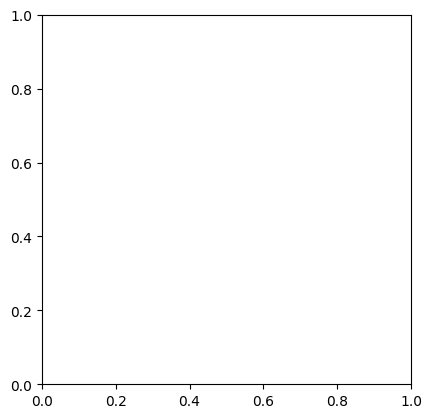

In [85]:
roads_gdf.iloc[:100].buffer(100).plot()

In [81]:
roads_gdf = roads_gdf.to_crs(INDIA_PROJECTED_CRS)

In [82]:
# filter roads to only those inside the output_parcel_gdf
roads_gdf = roads_gdf[roads_gdf.geometry.intersects(output_parcel_gdf.geometry.unary_union)]

In [83]:
roads_gdf

,u,v,key,osmid,ref,highway,oneway,reversed,length,from,to,geometry,bridge,tunnel,lanes,maxspeed,junction,name


## Merge in selected groupings and get stats

In [112]:
import shapely

In [113]:
suggested_parcels_gdf = gpd.read_file(OUTPUT_DATA_DIR / "Morena" / "Suggested Parcels.kml").to_crs(epsg=INDIA_PROJECTED_CRS)
suggested_parcels_gdf.geometry = suggested_parcels_gdf.geometry.apply(
    lambda x: shapely.wkb.loads(shapely.wkb.dumps(x, output_dimension=2))
)
suggested_parcels_gdf.drop(columns=["Description"], inplace=True)
suggested_parcels_gdf.rename(columns={"Name": "Parcel Name"}, inplace=True)

In [114]:
filtered_parcel_gdf = output_parcel_gdf.sjoin(suggested_parcels_gdf, predicate="within").drop(columns=["index_right"])
filtered_parcel_gdf

,Khasra Name,Description,source,Patch Name,geometry,Khasra ID (Unique),Original Area (ha),Unusable Area (ha),Usable Area (ha),Usable and Available Area (ha),...,Usable Area (%),Usable and Available Area (%),Usable but Unavailable Area (%),Unusable Area - Settlements (ha),Unavailable Area - Isolated Buildings (ha),Unusable Area - Water (ha),Unavailable Area - Cropland (ha),Unavailable Area - Slope (ha),Building Count,Parcel Name
21,47,Unknown Area Type<BR><BR><B>patch_name</B> = M...,joura,MRA10,"MULTIPOLYGON (((3702903.451 228344.492, 370290...",47 (MRA10),0.684168,0.0,0.684168,0.551500,...,100.0,80.608901,19.391099,0.0,0.0,0.0,0.132668,0.0,0.0,4
22,118,Unknown Area Type<BR><BR><B>patch_name</B> = M...,joura,MRA10,"MULTIPOLYGON (((3703083.155 228442.006, 370306...",118 (MRA10),34.251330,0.0,34.251330,33.646758,...,100.0,98.234895,1.765105,0.0,0.0,0.0,0.604572,0.0,0.0,4
23,109,Unknown Area Type<BR><BR><B>patch_name</B> = M...,joura,MRA18,"POLYGON ((3703839.928 228958.363, 3703839.343 ...",109 (MRA18),0.031907,0.0,0.031907,0.031907,...,100.0,100.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,4
24,111,Unknown Area Type<BR><BR><B>patch_name</B> = M...,joura,MRA18,"POLYGON ((3703809.886 228890.678, 3703793.269 ...",111 (MRA18),0.091648,0.0,0.091648,0.091648,...,100.0,100.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,4
25,95,Unknown Area Type<BR><BR><B>patch_name</B> = M...,joura,MRA18,"POLYGON ((3704139.807 229257.801, 3704128.501 ...",95 (MRA18),0.819901,0.0,0.819901,0.819901,...,100.0,100.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6732,452,Unknown Area Type<BR><BR><B>patch_name</B> = S...,vijaypur,SEO2767,"POLYGON ((3707786.613 238033.913, 3707785.921 ...",452 (SEO2767),0.387262,0.0,0.387262,0.194303,...,100.0,50.173593,49.826407,0.0,0.0,0.0,0.192959,0.0,0.0,7
7786,69,Unknown Area Type<BR><BR><B>patch_name</B> = S...,vijaypur,SEO2658,"POLYGON ((3703538.655 236358.613, 3703536.978 ...",69 (SEO2658),0.004885,0.0,0.004885,0.004885,...,100.0,100.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,7
7787,286,Unknown Area Type<BR><BR><B>patch_name</B> = S...,vijaypur,SEO2658,"POLYGON ((3703538.655 236358.613, 3703536.978 ...",286 (SEO2658),0.004885,0.0,0.004885,0.004885,...,100.0,100.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,7
7788,151,Unknown Area Type<BR><BR><B>patch_name</B> = S...,vijaypur,SEO2725,"POLYGON ((3706730.126 238082.521, 3706729.784 ...",151 (SEO2725),0.345914,0.0,0.345914,0.345914,...,100.0,100.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,7


In [115]:
parcel_level_stats_df = (
    filtered_parcel_gdf.drop(columns=["Khasra Name", "Patch Name", "Khasra ID (Unique)", "Description", "source", "geometry"])
    .groupby("Parcel Name")
    .sum()
    .round(2)
)

In [116]:
# make two columns, one count, one list of all names that fall inside this parcel. list should just be formatted as a long string
count_filtered_parcel_gdf = filtered_parcel_gdf.groupby("Parcel Name").agg(
    khasra_count=("Khasra ID (Unique)", "size"),
    khasra_names=("Khasra ID (Unique)", lambda x: ", ".join(list(x)))
)

In [117]:
# combine
parcel_level_stats_df = parcel_level_stats_df.merge(count_filtered_parcel_gdf, on="Parcel Name")

In [118]:
parcel_level_stats_df

,Original Area (ha),Unusable Area (ha),Usable Area (ha),Usable and Available Area (ha),Usable but Unavailable Area (ha),Unusable Area (%),Usable Area (%),Usable and Available Area (%),Usable but Unavailable Area (%),Unusable Area - Settlements (ha),Unavailable Area - Isolated Buildings (ha),Unusable Area - Water (ha),Unavailable Area - Cropland (ha),Unavailable Area - Slope (ha),Building Count,khasra_count,khasra_names
Parcel Name,,,,,,,,,,,,,,,,,
1,173.69,0.0,173.69,150.40,23.30,0.00,4000.00,3006.93,993.07,0.0,0.48,0.0,22.80,0.11,3.0,40,"1065 (SEO2115), 1066 (SEO2115), 1067 (SEO2115)..."
2,253.99,0.0,253.99,184.13,69.86,0.00,8800.00,5778.94,3021.06,0.0,2.94,0.0,77.92,0.00,16.0,88,"652 (SEO1996), 655 (SEO1996), 651 (SEO1996), 6..."
3,136.24,0.0,136.24,117.36,18.88,0.00,5800.00,3217.55,2582.45,0.0,0.83,0.0,23.62,0.09,6.0,58,"896 (SEO2227), 904 (SEO2227), 931 (SEO2227), 9..."
4,137.14,0.0,137.14,90.01,47.14,0.00,5700.00,3335.45,2364.55,0.0,1.38,0.0,46.69,0.00,10.0,57,"47 (MRA10), 118 (MRA10), 109 (MRA18), 111 (MRA..."
5,78.37,0.0,78.37,64.77,13.60,0.00,2900.00,1488.07,1411.93,0.0,0.30,0.0,13.59,0.00,3.0,29,"1589 (SEO2419), 1626 (SEO2419), 1621 (SEO2419)..."
6,174.49,0.4,174.09,118.50,55.59,151.05,10948.95,8547.74,2401.22,0.4,0.26,0.0,55.83,0.00,8.0,111,"280 (SEO2524), 264 (SEO2524), 262 (SEO2524), 2..."
7,329.93,1.8,328.14,210.05,118.08,100.48,12399.52,8333.74,4065.77,1.8,1.16,0.0,118.73,0.00,27.0,125,"628 (SEO2650), 629 (SEO2650), 630 (SEO2650), 6..."


In [119]:
parcel_level_stats_df.to_csv(
    OUTPUT_DATA_DIR / "Morena" / "suggested_parcels_stats.csv"
)

In [77]:
buildings_overlap_gdf[buildings_overlap_gdf["Khasra ID (Unique)"] == "628 (SEO2650)"]

,bf_source,confidence,area_in_meters,rooftop_id,Khasra Name,Description,source,Patch Name,Khasra ID (Unique),geometry,settlement_id
6278,microsoft,NaN,18.0229,ROOFTOP_S2_4140778382390460416_1528955,628,Unknown Area Type<BR><BR><B>patch_name</B> = S...,vijaypur,SEO2650,628 (SEO2650),"POLYGON ((3705188.744 235724.092, 3705186.518 ...",-1
6279,google,0.6623,18.0724,ROOFTOP_S2_4140778382390460416_1528965,628,Unknown Area Type<BR><BR><B>patch_name</B> = S...,vijaypur,SEO2650,628 (SEO2650),"POLYGON ((3705538.234 235501.758, 3705537.816 ...",195
6280,google,0.7047,38.1223,ROOFTOP_S2_4140778382390460416_1528966,628,Unknown Area Type<BR><BR><B>patch_name</B> = S...,vijaypur,SEO2650,628 (SEO2650),"POLYGON ((3705540.096 235501.599, 3705539.272 ...",195
6281,google,0.7564,31.8083,ROOFTOP_S2_4140778382390460416_1528967,628,Unknown Area Type<BR><BR><B>patch_name</B> = S...,vijaypur,SEO2650,628 (SEO2650),"POLYGON ((3705586.355 235583.119, 3705584.398 ...",195
6282,google,0.7225,20.3698,ROOFTOP_S2_4140778382390460416_1528968,628,Unknown Area Type<BR><BR><B>patch_name</B> = S...,vijaypur,SEO2650,628 (SEO2650),"POLYGON ((3705584.857 235590.430, 3705583.083 ...",195
